In [37]:
import numpy as np
import pennylane as qml
import numpy.polynomial.chebyshev as C
import matplotlib.pyplot as plt
import torch
from functools import reduce

np.random.seed(5)

# ==========================
# Hyperparameters
# ==========================
n_qubits = 1
L = 3
Nx_u = 50
Nx_fit = 50
deg_max = 15
blocks = 2
n_samples = 20   # Monte Carlo samples

dev = qml.device("default.qubit", wires=n_qubits)

def Observable_local(n, device='cpu', dtype=torch.float32):
    """
    Returns the operator O_L = (1/n) * sum_j (|0><0|_j ⊗ I_{rest})
    as a 2^n x 2^n tensor.
    """
    # single-qubit projectors and identity
    P0 = torch.tensor([[1., 0.],
                       [0., 0.]], device=device, dtype=dtype)
    I2 = torch.eye(2, device=device, dtype=dtype)

    # accumulate sum of tensor-products
    OL = torch.zeros((2**n, 2**n), device=device, dtype=dtype)
    for j in range(n):
        # build list of n factors: P0 at position j, I elsewhere
        factors = [P0 if k == j else I2 for k in range(n)]
        # take the n-fold Kronecker product
        op_j = reduce(lambda A, B: torch.kron(A, B), factors)
        OL += op_j

    # average
    return OL / n

O_L = Observable_local(n_qubits).numpy()

# ==========================
# Encodings
# ==========================
def pauli_encoding(x, sign):
    for w in range(n_qubits):
        qml.RX(sign * x, wires=w)

# def novel_exp_encoding(x, layer, sign):
#     """
#     x is assumed in [-1, 1].
#     """
#     eta = 3**(n_qubits*layer)
#     phi = sign * x
#     angle1 = eta * phi * 3.0
#     angle2 = eta * phi
#     qml.RZ(angle1, wires=0)
#     qml.RZ(angle2, wires=1)

def novel_exp_encoding(x, layer, sign):
    phi = sign * x
    for n in range(1, n_qubits+1):
        coef = 3 ** (n_qubits * layer - n)
        qml.RZ(coef * phi, wires=(n-1))

@qml.qnode(dev)
def circuit_QFM(x, weights):
    qml.templates.StronglyEntanglingLayers(
        weights[0], wires=range(n_qubits)
    )
    for l in range(L):
        # pauli_encoding(x, 1)
        novel_exp_encoding(x, l+1, 1)
        qml.templates.StronglyEntanglingLayers(
            weights[l+1], wires=range(n_qubits)
        )
    return qml.expval(qml.Hermitian(O_L, wires=range(n_qubits)))
    # return qml.expval(qml.PauliZ(0))

@qml.qnode(dev)
def circuit_QCM(x, weights, sign):
    qml.templates.StronglyEntanglingLayers(
        weights[0], wires=range(n_qubits)
    )
    for l in range(L):
        # pauli_encoding(np.arccos(x), sign)
        novel_exp_encoding(np.arccos(x), l+1, sign)
        qml.templates.StronglyEntanglingLayers(
            weights[l+1], wires=range(n_qubits)
        )
    return qml.expval(qml.Hermitian(O_L, wires=range(n_qubits)))
    # return qml.expval(qml.PauliZ(0))

# ==========================
# Storage
# ==========================
coeffs_QFM = []
coeffs_QCM = []

# ==========================
# Monte Carlo loop
# ==========================
for sample in range(n_samples):

    weights = np.random.uniform(
        0, 2*np.pi,
        size=(L+1, blocks, n_qubits, 3)
    )

    # --------------------------------
    # QFM : FFT-based Chebyshev
    # --------------------------------
    u_grid = np.linspace(0, 2*np.pi, Nx_u, endpoint=False)
    f_u = np.array([circuit_QFM(u, weights) for u in u_grid])

    c_fft = np.fft.fft(f_u) / Nx_u

    a_fft = np.zeros(deg_max + 1, dtype=complex)
    a_fft[0] = c_fft[0]
    for n in range(1, deg_max + 1):
        a_fft[n] = c_fft[n]

    coeffs_QFM.append(a_fft)

    # --------------------------------
    # QCM : chebfit
    # --------------------------------
    x_grid = np.linspace(-1, 1, Nx_fit)
    y_vals = np.array([
        (circuit_QCM(x, weights, 1) +
         circuit_QCM(x, weights, -1)) / 2
        for x in x_grid
    ])

    a_cheb = C.chebfit(x_grid, y_vals, deg=deg_max)
    coeffs_QCM.append(a_cheb)

# ==========================
# Convert to arrays
# ==========================
coeffs_QFM = np.array(coeffs_QFM)
coeffs_QCM = np.array(coeffs_QCM)

# ==========================
# Compute variance
# ==========================
var_QFM = np.var(coeffs_QFM, axis=0)
var_QCM = np.var(coeffs_QCM, axis=0)

orders = np.arange(deg_max + 1)

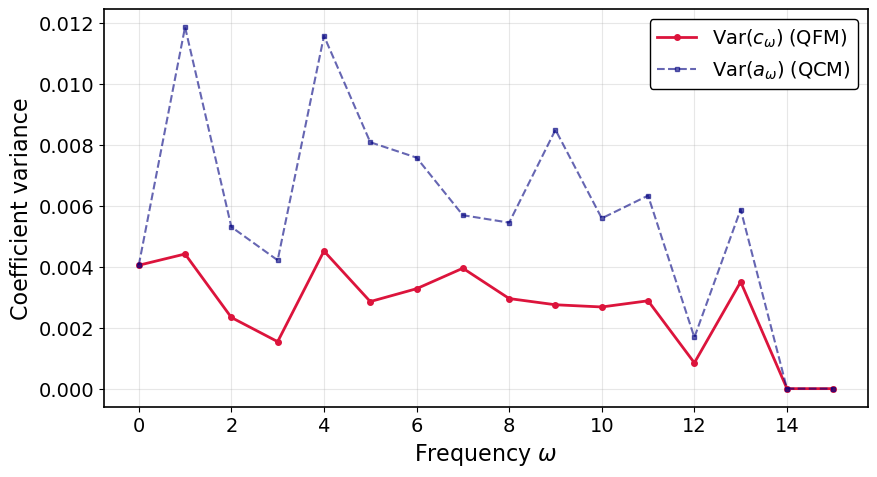

In [38]:
# ==========================
# Plot
# ==========================
import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 14,          # 基础字体
    "axes.labelsize": 16,     # x,y 轴标题
    "axes.titlesize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "axes.linewidth": 1.2,    # 坐标轴线宽
})
# mpl.rcParams["mathtext.fontset"] = "stix"
# mpl.rcParams["mathtext.fontset"] = "cm"
mpl.rcParams["mathtext.fontset"] = "dejavusans"

size = 6
cutoff = 40

plt.figure(figsize=(9,5))
plt.plot(orders, var_QFM, 'o', color='crimson', linestyle='-', markersize=4, linewidth=2, alpha=1.0,label=r"$\operatorname{Var}(c_\omega)\;(\mathrm{QFM})$")
plt.plot(orders, var_QCM, 's', color='navy', linestyle='--', markersize=2.5, linewidth=1.5, alpha=0.6, label=r"$\operatorname{Var}(a_\omega)\;(\mathrm{QCM})$")
# plt.axvline(x=cutoff, color='r', linestyle='--', alpha=0.8, label=r"$\omega_{\max}$")
plt.xlabel(r"Frequency $\omega$")
plt.ylabel("Coefficient variance")
plt.grid(alpha=0.3)
plt.legend(
    loc="upper right",
    framealpha=1.0,
    facecolor="white",
    edgecolor="black"
)
# plt.yscale("symlog", linthresh=1e-4)
# plt.ylim(-2e-5, 1e-2)
plt.tight_layout()
plt.show()

In [67]:
import numpy as np
import pennylane as qml
import numpy.polynomial.chebyshev as C
import matplotlib.pyplot as plt
import torch
from functools import reduce
import itertools

# ==========================
# Reproducibility
# ==========================
np.random.seed(5)

# ==========================
# Hyperparameters
# ==========================
m = 2
n_qubits = 2
L = 2
Nx_u = 12
Nx_fit = 12
deg_max = 5
blocks = 2
n_samples = 10

dev = qml.device("default.qubit", wires=n_qubits)

# ==========================
# Observable
# ==========================
def Observable_local(n, device='cpu', dtype=torch.float32):
    P0 = torch.tensor([[1., 0.],
                       [0., 0.]], device=device, dtype=dtype)
    I2 = torch.eye(2, device=device, dtype=dtype)

    OL = torch.zeros((2**n, 2**n), device=device, dtype=dtype)
    for j in range(n):
        factors = [P0 if k == j else I2 for k in range(n)]
        op_j = reduce(lambda A, B: torch.kron(A, B), factors)
        OL += op_j

    return OL / n

O_L = Observable_local(n_qubits).numpy()

# ==========================
# Encoding
# ==========================
def novel_exp_encoding_multi(x_vec, layer):
    for j in range(m):
        phi = x_vec[j]
        coef = 3 ** layer
        qml.RZ(coef * phi, wires=j)
        
# ==========================
# Circuits
# ==========================
@qml.qnode(dev)
def circuit_QFM(u_vec, weights):
    qml.templates.StronglyEntanglingLayers(weights[0], wires=range(n_qubits))
    for l in range(L):
        novel_exp_encoding_multi(u_vec, l)
        qml.templates.StronglyEntanglingLayers(weights[l+1], wires=range(n_qubits))
    return qml.expval(qml.Hermitian(O_L, wires=range(n_qubits)))

@qml.qnode(dev)
def circuit_QCM(x_vec, weights, sign_vec):
    qml.templates.StronglyEntanglingLayers(weights[0], wires=range(n_qubits))
    for l in range(L):
        signed = np.arccos(x_vec) * sign_vec
        novel_exp_encoding_multi(signed, l)
        qml.templates.StronglyEntanglingLayers(weights[l+1], wires=range(n_qubits))
    return qml.expval(qml.Hermitian(O_L, wires=range(n_qubits)))

# ==========================
# QFM 2D FFT
# ==========================
def qfm_coeffs_2d_fft(weights):
    u = np.linspace(0, 2*np.pi, Nx_u, endpoint=False)
    f = np.zeros((Nx_u, Nx_u))

    for i in range(Nx_u):
        for j in range(Nx_u):
            f[i,j] = circuit_QFM(np.array([u[i], u[j]]), weights)

    c_fft = np.fft.fftn(f) / (Nx_u**2)
    return c_fft[:deg_max+1, :deg_max+1]

# ==========================
# QCM 2D Chebyshev (full sign average)
# ==========================
def qcm_coeffs_2d_chebfit(weights):

    x = np.linspace(-1, 1, Nx_fit)
    X1, X2 = np.meshgrid(x, x, indexing='ij')

    y = np.zeros_like(X1)

    sign_list = list(itertools.product([-1, 1], repeat=m))

    for i in range(Nx_fit):
        for j in range(Nx_fit):
            xv = np.array([X1[i,j], X2[i,j]])

            y_val = 0.0
            for s in sign_list:
                s_vec = np.array(s)
                y_val += circuit_QCM(xv, weights, s_vec)

            y[i,j] = y_val / (2**m)

    x1_flat = X1.ravel()
    x2_flat = X2.ravel()
    y_flat  = y.ravel()

    V = C.chebvander2d(x1_flat, x2_flat, [deg_max, deg_max])

    coeffs_flat, *_ = np.linalg.lstsq(V, y_flat, rcond=None)

    coeffs = coeffs_flat.reshape(deg_max+1, deg_max+1)

    # Reconstruction validation
    y_recon = C.chebval2d(X1, X2, coeffs)
    recon_error = np.mean((y_recon - y)**2)
    print("Reconstruction MSE:", recon_error)

    return coeffs

# ==========================
# Monte Carlo
# ==========================
coeffs_QFM = []
coeffs_QCM = []

for sample in range(n_samples):

    weights = np.random.uniform(
        0, 2*np.pi,
        size=(L+1, blocks, n_qubits, 3)
    )

    c_qfm = qfm_coeffs_2d_fft(weights)
    a_qcm = qcm_coeffs_2d_chebfit(weights)

    coeffs_QFM.append(c_qfm)
    coeffs_QCM.append(a_qcm)

coeffs_QFM_real = np.array(coeffs_QFM)
coeffs_QCM_real = np.array(coeffs_QCM)


Reconstruction MSE: 8.54642112432638e-31
Reconstruction MSE: 2.139708168214219e-31
Reconstruction MSE: 5.460011392337814e-31
Reconstruction MSE: 4.294302169956931e-31
Reconstruction MSE: 7.668250567739812e-31
Reconstruction MSE: 9.369435187227859e-31
Reconstruction MSE: 1.3241196352094333e-30
Reconstruction MSE: 8.469865409036988e-31
Reconstruction MSE: 1.516862424199387e-30
Reconstruction MSE: 6.126597145311841e-31


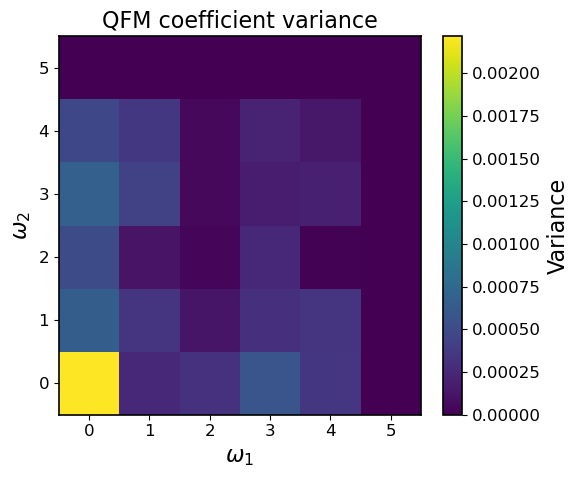

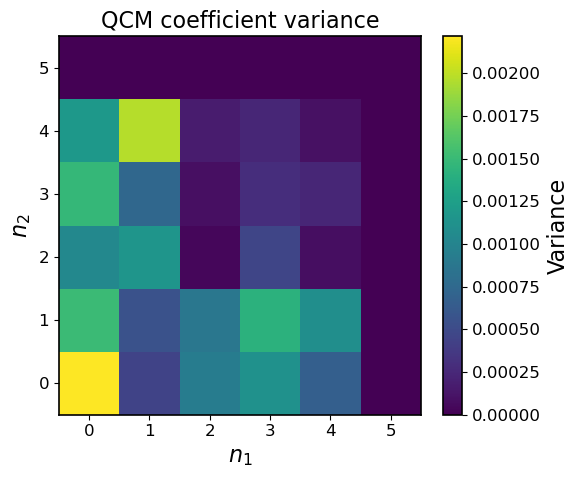

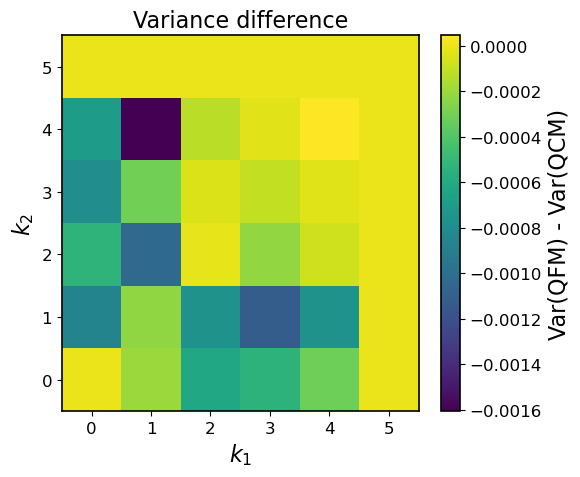

In [59]:
# ==========================
# Variance
# ==========================
var_QFM = np.var(coeffs_QFM, axis=0)
var_QCM = np.var(coeffs_QCM, axis=0)

# ==========================
# Plot
# ==========================
import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.2,
})
mpl.rcParams["mathtext.fontset"] = "dejavusans"

plt.figure(figsize=(6,5))
plt.imshow(var_QFM, origin="lower", aspect="auto")
plt.colorbar(label="Variance")
plt.xlabel(r"$\omega_1$")
plt.ylabel(r"$\omega_2$")
plt.title("QFM coefficient variance")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,5))
plt.imshow(var_QCM, origin="lower", aspect="auto")
plt.colorbar(label="Variance")
plt.xlabel(r"$n_1$")
plt.ylabel(r"$n_2$")
plt.title("QCM coefficient variance")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,5))
plt.imshow(var_QFM - var_QCM, origin="lower", aspect="auto")
plt.colorbar(label="Var(QFM) - Var(QCM)")
plt.xlabel(r"$k_1$")
plt.ylabel(r"$k_2$")
plt.title("Variance difference")
plt.tight_layout()
plt.show()

# Multi-variable case

In [62]:
import numpy as np
import pennylane as qml
import numpy.polynomial.chebyshev as C
import matplotlib.pyplot as plt
import torch
from functools import reduce
import itertools

# ==========================
# Reproducibility
# ==========================
np.random.seed(5)

# ==========================
# Hyperparameters
# ==========================
m = 2
n_qubits = m
L = 2
Nx_u = 12
Nx_fit = 12
deg_max = 5
blocks = 2
n_samples = 10

# safety: avoid aliasing when accessing +/- frequencies up to deg_max
assert Nx_u > 2 * deg_max + 1, "Need Nx_u > 2*deg_max+1 to avoid FFT aliasing for +/- frequencies."

dev = qml.device("default.qubit", wires=n_qubits)

# ==========================
# Observable
# ==========================
def Observable_local(n, device='cpu', dtype=torch.float32):
    P0 = torch.tensor([[1., 0.],
                       [0., 0.]], device=device, dtype=dtype)
    I2 = torch.eye(2, device=device, dtype=dtype)

    OL = torch.zeros((2**n, 2**n), device=device, dtype=dtype)
    for j in range(n):
        factors = [P0 if k == j else I2 for k in range(n)]
        op_j = reduce(lambda A, B: torch.kron(A, B), factors)
        OL += op_j
    return OL / n

O_L = Observable_local(n_qubits).numpy()

# ==========================
# Encoding
# ==========================
def novel_exp_encoding_multi(x_vec, layer):
    for j in range(m):
        phi = x_vec[j]
        coef = 3 ** layer
        qml.RZ(coef * phi, wires=j)

# ==========================
# Circuits
# ==========================
@qml.qnode(dev)
def circuit_QFM(u_vec, weights):
    qml.templates.StronglyEntanglingLayers(weights[0], wires=range(n_qubits))
    for l in range(L):
        novel_exp_encoding_multi(u_vec, l)
        qml.templates.StronglyEntanglingLayers(weights[l+1], wires=range(n_qubits))
    return qml.expval(qml.Hermitian(O_L, wires=range(n_qubits)))


# ==========================
# Helpers: FFT coefficient access with negative frequencies
# ==========================
def fft_idx(w, N):
    """Map integer frequency w (can be negative) to numpy FFT index."""
    return w % N

def c_from_fft(c_fft, w1, w2):
    """Get c_{(w1,w2)} from full 2D FFT array."""
    return c_fft[fft_idx(w1, c_fft.shape[0]), fft_idx(w2, c_fft.shape[1])]

# ==========================
# QFM: compute full 2D FFT coefficients
# ==========================
def qfm_fft_full(weights):
    u = np.linspace(0, 2*np.pi, Nx_u, endpoint=False)
    f = np.zeros((Nx_u, Nx_u), dtype=float)
    for i in range(Nx_u):
        for j in range(Nx_u):
            f[i, j] = circuit_QFM(np.array([u[i], u[j]]), weights)
    c_fft = np.fft.fftn(f) / (Nx_u**2)  # full complex array shape (Nx_u,Nx_u)
    return c_fft


# ==========================
# Verify: a_nu from FFT (two ways) and compare with Cheb fit
# ==========================

def a_from_fft_abs(c_fft, nu):
    """
    Compute
        a_nu = sum_{omega : |omega| = nu} c_omega
    using full FFT array.
    """
    nu = np.asarray(nu, dtype=int)

    total = 0.0 + 0.0j

    # enumerate all possible omega in range [-deg_max,deg_max]
    # but only those with |omega|=nu contribute
    for w1 in range(-nu[0], nu[0]+1):
        if abs(w1) != nu[0]:
            continue
        for w2 in range(-nu[1], nu[1]+1):
            if abs(w2) != nu[1]:
                continue
            total += c_from_fft(c_fft, w1, w2)
    return total


# ==========================
# Monte Carlo loop
# ==========================
coeffs_QFM = []
coeffs_QCM = []
var_checks = []  # store per-sample verification errors

for sample in range(n_samples):

    weights = np.random.uniform(
        0, 2*np.pi,
        size=(L+1, blocks, n_qubits, 3)
    )

    # --- QFM full FFT coefficients ---
    c_fft = qfm_fft_full(weights)


    # --- build a_nu from FFT two ways on grid 0..deg_max ---
    a_cheb = np.zeros((deg_max+1, deg_max+1), dtype=complex)
    a_fourier = np.zeros((deg_max+1, deg_max+1), dtype=complex)

    for n1 in range(deg_max+1):
        for n2 in range(deg_max+1):
            nu = (n1, n2)
            a_cheb[n1,n2]  = a_from_fft_abs(c_fft, nu)
            
    for n1 in range(deg_max+1):
        for n2 in range(deg_max+1):
            a_fourier[n1, n2] = c_from_fft(c_fft, n1, n2)

    # --- verification metrics ---

    err_half_cheb = np.max(np.abs(a_fourier - a_cheb))

    # store for variance plot (keep the "a" objects you care about)
    coeffs_QFM.append(a_fourier)      # these are the collapsed a_nu computed from FFT full-sign sum
    coeffs_QCM.append(a_cheb)      # these are the fitted cheb coefficients

    var_checks.append(err_half_cheb)

coeffs_QFM = np.array(coeffs_QFM)  # (n_samples, deg+1, deg+1), complex (should be ~real)
coeffs_QCM = np.array(coeffs_QCM)  # (n_samples, deg+1, deg+1), real

# ==========================
# Variance (keep your original plotting intent)
# ==========================
var_QFM = np.var(coeffs_QFM, axis=0)
var_QCM = np.var(coeffs_QCM, axis=0)

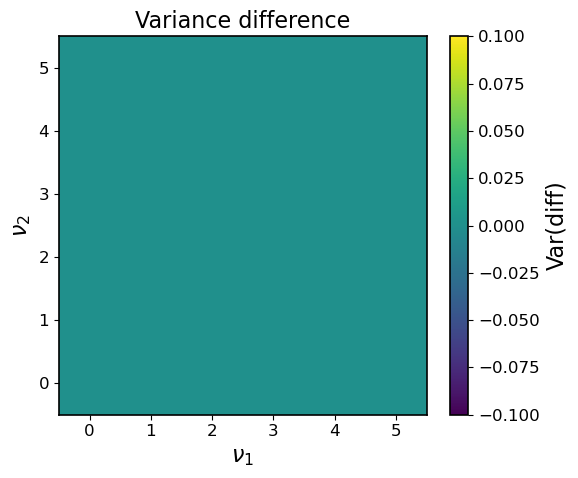

In [69]:
var_QCM_real = np.var(coeffs_QCM_real, axis=0)
var_QFM_real = np.var(coeffs_QFM_real, axis=0)

plt.figure(figsize=(6,5))
plt.imshow(var_QFM_real - var_QFM, origin="lower", aspect="auto")
plt.colorbar(label="Var(diff)")
plt.xlabel(r"$\nu_1$")
plt.ylabel(r"$\nu_2$")
plt.title("Variance difference")
plt.tight_layout()
plt.show()

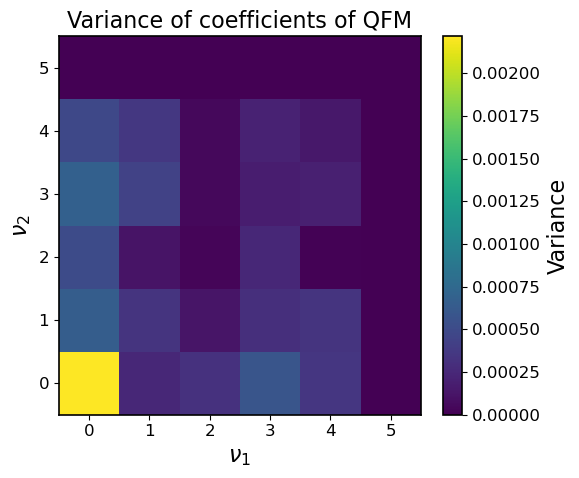

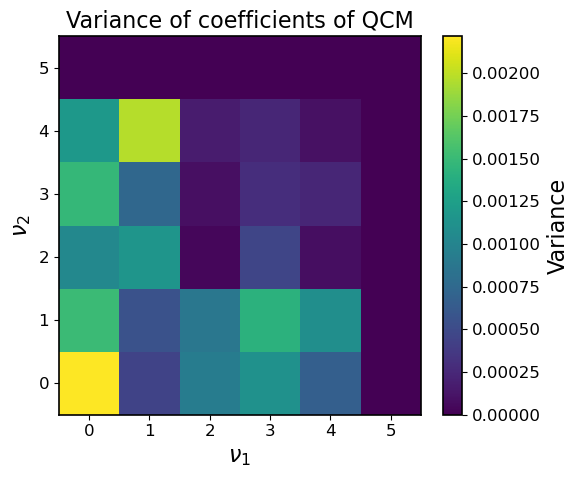

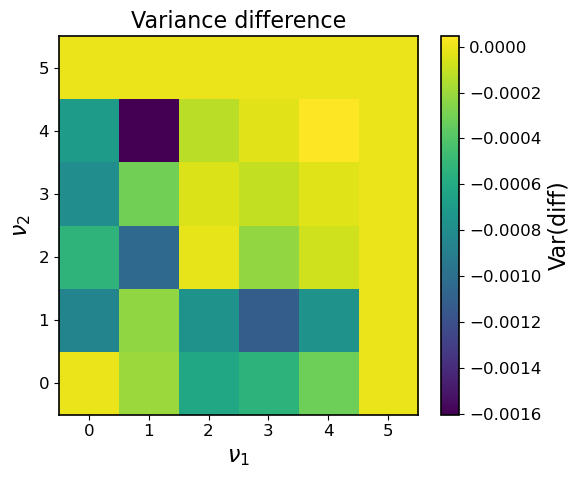

In [64]:
# ==========================
# Plot
# ==========================
import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.2,
})
mpl.rcParams["mathtext.fontset"] = "dejavusans"

plt.figure(figsize=(6,5))
plt.imshow(var_QFM, origin="lower", aspect="auto")
plt.colorbar(label="Variance")
plt.xlabel(r"$\nu_1$")
plt.ylabel(r"$\nu_2$")
plt.title("Variance of coefficients of QFM")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,5))
plt.imshow(var_QCM, origin="lower", aspect="auto")
plt.colorbar(label="Variance")
plt.xlabel(r"$\nu_1$")
plt.ylabel(r"$\nu_2$")
plt.title("Variance of coefficients of QCM")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,5))
plt.imshow(var_QFM - var_QCM, origin="lower", aspect="auto")
plt.colorbar(label="Var(diff)")
plt.xlabel(r"$\nu_1$")
plt.ylabel(r"$\nu_2$")
plt.title("Variance difference")
plt.tight_layout()
plt.show()